# Bài tập Môn Học Trí Tuệ Nhân Tạo - EE3063
## Đề tài: Phân tích và Dự đoán Giá Xe Audi Sử dụng Hồi quy Tuyến tính và K-Láng Giềng Gần Nhất (KNN)

Nhóm Thực Hiện: [Điền tên thành viên nhóm]
MSSV: [Điền MSSV thành viên nhóm]

Nội dung file:
1. Tải và tiền xử lý dữ liệu giá xe Audi.
2. Xây dựng mô hình hồi quy tuyến tính đơn biến cho 'mileage' và 'engineSize'.
3. Xây dựng hàm dự đoán giá kết hợp KNN và hồi quy tuyến tính cục bộ.
4. Trực quan hóa kết quả.
5. In ra một vài dự đoán mẫu.

In [ ]:
# -*- coding: utf-8 -*-
# Thư viện cần thiết
import csv
import requests # Để tải dữ liệu từ URL
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # Sử dụng để chuẩn hóa dữ liệu cho KNN
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression

## Phần 1: Tải và Tiền xử lý Dữ liệu

Giải thích:

- Dữ liệu giá xe Audi được tải từ một URL công khai trên GitHub.

- Dữ liệu ở định dạng CSV và được đọc bằng thư viện csv.

-  Chúng ta sẽ trích xuất các cột quan trọng: 'mileage' (số km đã đi),

-  'engineSize' (kích thước động cơ), và 'price' (giá xe).

In [5]:
# Tải dữ liệu dataset
url = 'https://raw.githubusercontent.com/ntthang-dev/AI_Control_HCMUT_EE3063_Spring2025/main/datasets/audi.csv'
response = requests.get(url)
data = [column for column in csv.reader(response.text.splitlines())]

# Trích xuất các cột dữ liệu cần thiết từ cột thứ 2 trở đi (bỏ qua header)
# Cột 4: mileage, Cột 7: engineSize, Cột 2: price
mileage = np.array([float(column[4]) for column in data[1:]])
engineSize = np.array([float(column[7]) for column in data[1:]])
price = np.array([float(column[2]) for column in data[1:]])

# Để giảm thời gian tính toán và dễ trực quan hóa, ta lấy một mẫu ngẫu nhiên gồm 500 điểm dữ liệu.
np.random.seed(42) # Đảm bảo kết quả lặp lại được
sample_size = 500
indices = np.random.choice(len(mileage), sample_size, replace=False)

mileage_sample = mileage[indices]
engineSize_sample = engineSize[indices]
price_sample = price[indices]

# Kết hợp 'mileage' và 'engineSize' thành ma trận đặc trưng X
# Biến mục tiêu y là 'price'
X_sample = np.column_stack((mileage_sample, engineSize_sample))
y_sample = price_sample

### Chuẩn hóa dữ liệu cho KNN

Giải thích: KNN là thuật toán nhạy cảm với thang đo của dữ liệu.

- Các đặc trưng có thang đo lớn hơn có thể lấn át các đặc trưng có thang đo nhỏ hơn.

- StandardScaler sẽ chuẩn hóa dữ liệu bằng cách trừ đi giá trị trung bình và chia cho độ lệch chuẩn,

- đưa các đặc trưng về cùng một thang đo (trung bình 0, phương sai 1).

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)


## Phần 2: Xây dựng Hàm Dự đoán Kết hợp KNN và Hồi quy Tuyến tính Cục bộ

Giải thích thuật toán KNN + Hồi quy Tuyến tính Cục bộ:

Thay vì gán nhãn lớp (trong bài toán phân loại) hoặc giá trị trung bình của k láng giềng (trong KNN regression cơ bản),

phương pháp này thực hiện một bước tinh vi hơn:

1. Với mỗi điểm dữ liệu kiểm thử (test_point):

   a. Tìm k láng giềng gần nhất (X_neighbors, y_neighbors) từ tập dữ liệu huấn luyện (X_scaled, y).

   b. Xây dựng một mô hình hồi quy tuyến tính *cục bộ* chỉ dựa trên k láng giềng này.
      Nghĩa là, chúng ta "fit" một đường thẳng (hoặc siêu phẳng) nhỏ qua k điểm láng giềng đó.

   c. Sử dụng mô hình hồi quy tuyến tính cục bộ vừa xây dựng để dự đoán giá trị cho test_point.

Mục tiêu: Kết hợp sự linh hoạt của KNN (mô hình phi tham số, có thể bắt các mối quan hệ phức tạp)
với khả năng mô hình hóa xu hướng cục bộ của hồi quy tuyến tính.

In [9]:
def knn_lr_predict(X_train_scaled, y_train, X_test_scaled, k=5):
    """
    Dự đoán giá trị sử dụng KNN kết hợp hồi quy tuyến tính cục bộ.

    Args:
        X_train_scaled (np.array): Ma trận đặc trưng huấn luyện đã được chuẩn hóa.
        y_train (np.array): Vector giá trị mục tiêu huấn luyện.
        X_test_scaled (np.array): Ma trận đặc trưng kiểm thử đã được chuẩn hóa.
        k (int): Số lượng láng giềng gần nhất.

    Returns:
        list: Danh sách các giá trị dự đoán cho X_test_scaled.
    """
    # Khởi tạo mô hình KNN để tìm láng giềng
    # Lưu ý: Theo yêu cầu, phần này nên được tự build.
    # Ở đây đang dùng thư viện sklearn.neighbors.NearestNeighbors
    knn_finder = NearestNeighbors(n_neighbors=k, algorithm='auto')
    knn_finder.fit(X_train_scaled)

    # Khởi tạo mô hình Hồi quy Tuyến tính
    # Lưu ý: Theo yêu cầu, phần này nên được tự build.
    # Ở đây đang dùng thư viện sklearn.linear_model.LinearRegression
    lr_local = LinearRegression()

    predictions = []
    for test_point_scaled in X_test_scaled:
        # Tìm k láng giềng gần nhất cho điểm kiểm thử hiện tại
        # distances: khoảng cách, indices: chỉ số của các láng giềng trong tập huấn luyện
        distances, indices = knn_finder.kneighbors([test_point_scaled])

        # Lấy ra các đặc trưng và giá trị mục tiêu của k láng giềng
        X_neighbors_scaled = X_train_scaled[indices[0]]
        y_neighbors = y_train[indices[0]]

        # Huấn luyện mô hình hồi quy tuyến tính cục bộ trên k láng giềng này
        lr_local.fit(X_neighbors_scaled, y_neighbors)

        # Dự đoán giá trị cho điểm kiểm thử bằng mô hình hồi quy cục bộ
        pred = lr_local.predict([test_point_scaled])[0]
        predictions.append(pred)
    return predictions



## Phần 3: Xây dựng Mô hình Hồi quy Tuyến tính Đơn biến (Baseline)

Giải thích:

Để so sánh, chúng ta cũng xây dựng các mô hình hồi quy tuyến tính đơn biến:

1. Giá xe phụ thuộc vào số km đã đi (mileage).

2. Giá xe phụ thuộc vào kích thước động cơ (engineSize).

Các mô hình này sẽ đóng vai trò là baseline để đánh giá hiệu quả của phương pháp KNN + LR.

### 3.1. Hồi quy tuyến tính cho Mileage vs. Price


In [10]:
lr_mileage = LinearRegression()
# Reshape mileage_sample thành cột vector để fit mô hình
lr_mileage.fit(mileage_sample.reshape(-1, 1), y_sample)
mileage_pred_lr = lr_mileage.predict(mileage_sample.reshape(-1, 1))

### 3.2. Hồi quy tuyến tính cho Engine Size vs. Price


In [11]:
lr_engine = LinearRegression()
# Reshape engineSize_sample thành cột vector
lr_engine.fit(engineSize_sample.reshape(-1, 1), y_sample)
engine_pred_lr = lr_engine.predict(engineSize_sample.reshape(-1, 1))

## Phần 4: Thực hiện Dự đoán và Trực quan hóa Kết quả


Thực hiện dự đoán bằng KNN + LR cho toàn bộ tập mẫu (để vẽ đồ thị)

X_scaled được dùng làm cả tập huấn luyện và tập kiểm thử trong trường hợp này

để có thể vẽ đường dự đoán trên toàn bộ các điểm dữ liệu mẫu.

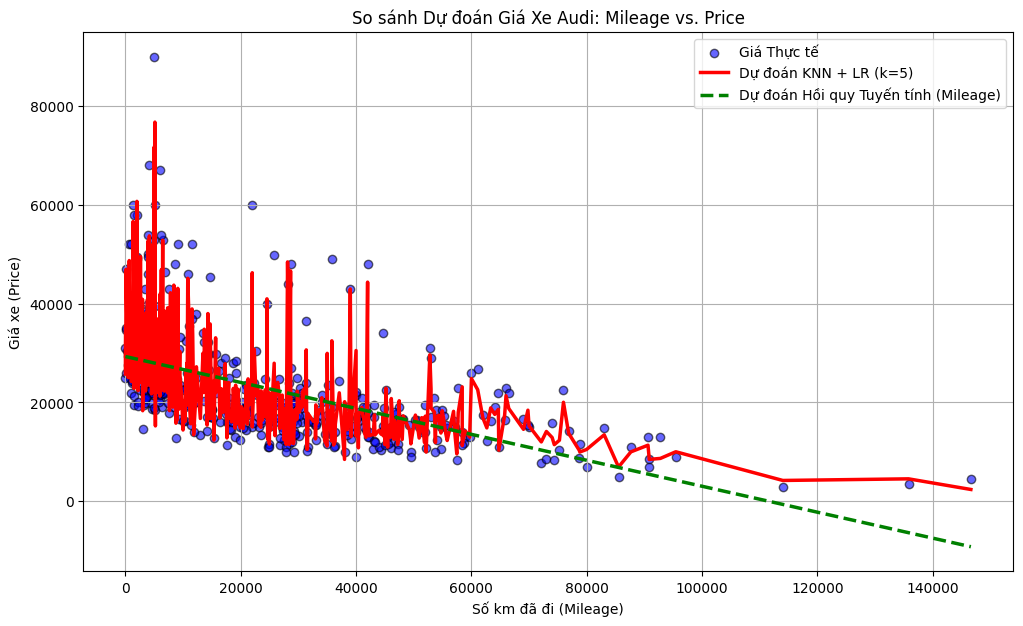

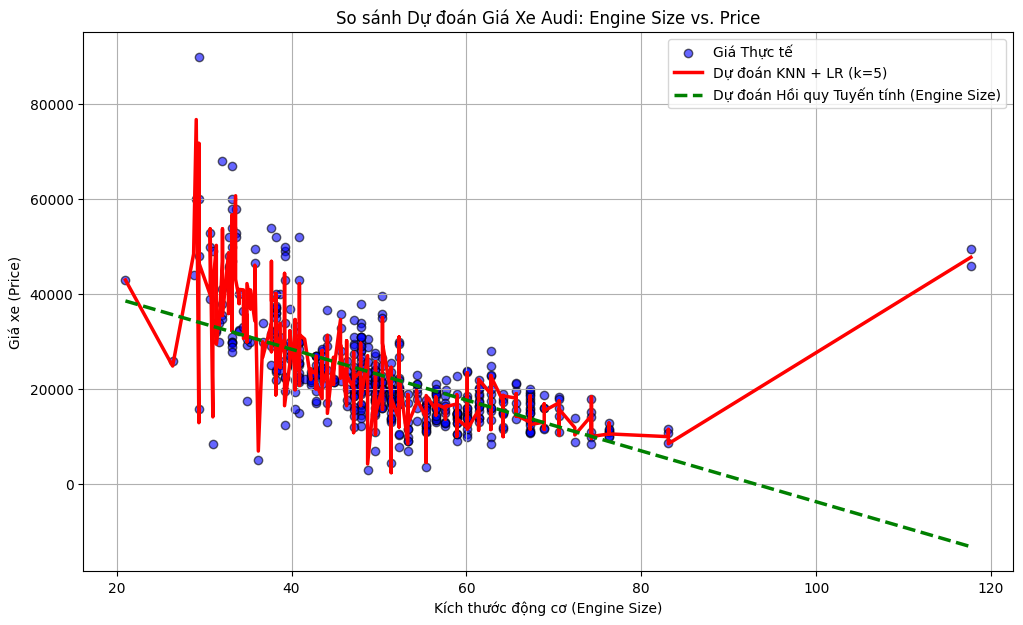

In [12]:
knn_lr_predictions_sample = knn_lr_predict(X_scaled, y_sample, X_scaled, k=5)

# Sắp xếp dữ liệu để vẽ đường KNN + LR một cách mượt mà
# Khi vẽ đường dự đoán của KNN, nếu các điểm không được sắp xếp theo trục hoành,
# đường nối các điểm dự đoán có thể bị gấp khúc và khó nhìn.

# Sắp xếp theo mileage
sorted_indices_mileage = np.argsort(mileage_sample)
sorted_mileage = mileage_sample[sorted_indices_mileage]
# Lấy các dự đoán KNN+LR tương ứng với các điểm đã sắp xếp theo mileage
sorted_knn_lr_mileage = np.array(knn_lr_predictions_sample)[sorted_indices_mileage]

# Sắp xếp theo engineSize
sorted_indices_engine = np.argsort(engineSize_sample)
sorted_engine = engineSize_sample[sorted_indices_engine]
# Lấy các dự đoán KNN+LR tương ứng với các điểm đã sắp xếp theo engineSize
sorted_knn_lr_engine = np.array(knn_lr_predictions_sample)[sorted_indices_engine]


# 4.1. Đồ thị: Mileage vs. Price
plt.figure(figsize=(12, 7)) # Kích thước đồ thị
# Vẽ các điểm dữ liệu thực tế
plt.scatter(mileage_sample, y_sample, c='blue', label='Giá Thực tế', alpha=0.6, edgecolor='k')
# Vẽ đường dự đoán của KNN + LR
plt.plot(sorted_mileage, sorted_knn_lr_mileage, c='red', label='Dự đoán KNN + LR (k=5)', linewidth=2.5)
# Vẽ đường dự đoán của Hồi quy tuyến tính đơn biến (mileage)
plt.plot(mileage_sample[sorted_indices_mileage], mileage_pred_lr[sorted_indices_mileage], c='green', label='Dự đoán Hồi quy Tuyến tính (Mileage)', linewidth=2.5, linestyle='--')

plt.xlabel('Số km đã đi (Mileage)')
plt.ylabel('Giá xe (Price)')
plt.title('So sánh Dự đoán Giá Xe Audi: Mileage vs. Price')
plt.legend() # Hiển thị chú thích
plt.grid(True) # Hiển thị lưới
plt.show()

# 4.2. Đồ thị: Engine Size vs. Price
plt.figure(figsize=(12, 7))
plt.scatter(engineSize_sample, y_sample, c='blue', label='Giá Thực tế', alpha=0.6, edgecolor='k')
plt.plot(sorted_engine, sorted_knn_lr_engine, c='red', label='Dự đoán KNN + LR (k=5)', linewidth=2.5)
plt.plot(engineSize_sample[sorted_indices_engine], engine_pred_lr[sorted_indices_engine], c='green', label='Dự đoán Hồi quy Tuyến tính (Engine Size)', linewidth=2.5, linestyle='--')

plt.xlabel('Kích thước động cơ (Engine Size)')
plt.ylabel('Giá xe (Price)')
plt.title('So sánh Dự đoán Giá Xe Audi: Engine Size vs. Price')
plt.legend()
plt.grid(True)
plt.show()

## Phần 5: In ra một vài dự đoán mẫu

Giải thích:

In ra 5 cặp giá trị (Thực tế, Dự đoán KNN+LR) đầu tiên trong tập mẫu
để có cái nhìn định lượng sơ bộ về độ chính xác của mô hình KNN + LR.

In [14]:
print("\nDự đoán Mẫu (Giá xe):")
for i in range(5): # In 5 mẫu đầu tiên
    print(f"Giá thực tế: {y_sample[i]:.2f}, Dự đoán (KNN + LR): {knn_lr_predictions_sample[i]:.2f}")


Dự đoán Mẫu (Giá xe):
Giá thực tế: 9990.00, Dự đoán (KNN + LR): 11618.96
Giá thực tế: 22382.00, Dự đoán (KNN + LR): 24350.60
Giá thực tế: 28990.00, Dự đoán (KNN + LR): 24906.78
Giá thực tế: 30777.00, Dự đoán (KNN + LR): 23926.08
Giá thực tế: 14950.00, Dự đoán (KNN + LR): 15062.70
